In [20]:
import os
import sys
import torch
import pandas as pd
import time
import matplotlib.pyplot as plt
import numpy as np
# Project root so "src" can be imported
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
print("Project root:", project_root)

if project_root not in sys.path:
    sys.path.append(project_root)

Project root: C:\Users\nlope\Desktop\week3\generative_transformer_project


In [2]:
from src.data import load_samsum_subset
from src.model import load_summarization_pipeline, generate_summary

In [4]:
gen = load_summarization_pipeline()
gen.keys()

Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

dict_keys(['tokenizer', 'model', 'device'])

In [5]:
dialogs, refs = load_samsum_subset(num_examples=3)

print("Number of examples:", len(dialogs))
print("\n=== Example 1 dialogue ===\n", dialogs[0])
print("\n=== Example 1 reference ===\n", refs[0])

Number of examples: 3

=== Example 1 dialogue ===
 Sam: Hey, are we still on for the meeting at 3?
Alex: Yes, but can we move it to 3:30?
Sam: That works for me.
Alex: Great, see you then.

=== Example 1 reference ===
 Sam and Alex reschedule their meeting from 3:00 to 3:30.


In [6]:
dialogue = dialogs[0]
reference = refs[0]

baseline = generate_summary(
    gen,
    dialogue,
    prompt_style="baseline",
    max_new_tokens=60,
    temperature=0.3,
)

improved = generate_summary(
    gen,
    dialogue,
    prompt_style="improved",
    max_new_tokens=60,
    temperature=0.3,
)

print("DIALOGUE:\n", dialogue)
print("\nREFERENCE:\n", reference)
print("\nBASELINE:\n", baseline)
print("\nIMPROVED:\n", improved)

DIALOGUE:
 Sam: Hey, are we still on for the meeting at 3?
Alex: Yes, but can we move it to 3:30?
Sam: That works for me.
Alex: Great, see you then.

REFERENCE:
 Sam and Alex reschedule their meeting from 3:00 to 3:30.

BASELINE:
 Sam and Alex agree to postpone the meeting to 3:30.

IMPROVED:
 Output: Sam and Alex agree to meet at 3:30.


In [7]:
from evaluate import load

metric = load("rouge")
metric

EvaluationModule(name: "rouge", module_type: "metric", features: [{'predictions': Value('string'), 'references': List(Value('string'))}, {'predictions': Value('string'), 'references': Value('string')}], usage: """
Calculates average rouge scores for a list of hypotheses and references
Args:
    predictions: list of predictions to score. Each prediction
        should be a string with tokens separated by spaces.
    references: list of reference for each prediction. Each
        reference should be a string with tokens separated by spaces.
    rouge_types: A list of rouge types to calculate.
        Valid names:
        `"rouge{n}"` (e.g. `"rouge1"`, `"rouge2"`) where: {n} is the n-gram based scoring,
        `"rougeL"`: Longest common subsequence based scoring.
        `"rougeLsum"`: rougeLsum splits text using `"
"`.
        See details in https://github.com/huggingface/datasets/issues/617
    use_stemmer: Bool indicating whether Porter stemmer should be used to strip word suffixes.
 

In [8]:
baseline_preds = []
improved_preds = []
baseline_scores = []
improved_scores = []

for i, (dialogue, reference) in enumerate(zip(dialogs, refs), start=1):
    baseline = generate_summary(
        gen,
        dialogue,
        prompt_style="baseline",
        max_new_tokens=60,
        temperature=0.3,
    )
    improved = generate_summary(
        gen,
        dialogue,
        prompt_style="improved",
        max_new_tokens=60,
        temperature=0.3,
    )

    baseline_preds.append(baseline)
    improved_preds.append(improved)

    # Compute Rouge scores
    base_result = metric.compute(predictions=[baseline], references=[reference])
    imp_result = metric.compute(predictions=[improved], references=[reference])

    # Each entry is already a float (aggregate F1); no .fmeasure attribute
    base_f1 = float(base_result["rougeL"])
    imp_f1 = float(imp_result["rougeL"])

    baseline_scores.append(base_f1)
    improved_scores.append(imp_f1)

    print(f"\n=== Example {i} ===")
    print("DIALOGUE:\n", dialogue)
    print("\nREFERENCE:\n", reference)
    print("\nBASELINE:\n", baseline)
    print("\nIMPROVED:\n", improved)
    print(f"\nBaseline Rouge-L F1:  {base_f1:.3f}")
    print(f"Improved Rouge-L F1:  {imp_f1:.3f}")
    print("-" * 80)


=== Example 1 ===
DIALOGUE:
 Sam: Hey, are we still on for the meeting at 3?
Alex: Yes, but can we move it to 3:30?
Sam: That works for me.
Alex: Great, see you then.

REFERENCE:
 Sam and Alex reschedule their meeting from 3:00 to 3:30.

BASELINE:
 Sam and Alex agree to meet at 3:30 for the meeting.

IMPROVED:
 The meeting is rescheduled to 3:30.

Baseline Rouge-L F1:  0.500
Improved Rouge-L F1:  0.421
--------------------------------------------------------------------------------

=== Example 2 ===
DIALOGUE:
 Mom: Did you finish your homework?
Kid: Almost, I have one assignment left.
Mom: Please finish before dinner.
Kid: Okay, I will.

REFERENCE:
 A mother reminds her child to finish homework before dinner.

BASELINE:
 Possible summary: - The kid almost finished their homework and promised to finish it before dinner. - One homework assignment was left and the kid agreed to complete it before dinner. - The kid was almost done with their homework and said they would finish it before 

In [14]:
start = time.time()

baseline_preds = []
improved_preds = []
baseline_scores = []
improved_scores = []

for i, (dialogue, reference) in enumerate(zip(dialogs, refs), start=1):
    baseline = generate_summary(
        gen,
        dialogue,
        prompt_style="baseline",
        max_new_tokens=60,
        temperature=0.3,
    )
    improved = generate_summary(
        gen,
        dialogue,
        prompt_style="improved",
        max_new_tokens=60,
        temperature=0.3,
    )

    baseline_preds.append(baseline)
    improved_preds.append(improved)

    base_result = metric.compute(predictions=[baseline], references=[reference])
    imp_result = metric.compute(predictions=[improved], references=[reference])

    base_f1 = float(base_result["rougeL"])
    imp_f1 = float(imp_result["rougeL"])

    baseline_scores.append(base_f1)
    improved_scores.append(imp_f1)

    print(f"\n=== Example {i} ===")
    print("DIALOGUE:\n", dialogue)
    print("\nREFERENCE:\n", reference)
    print("\nBASELINE:\n", baseline)
    print("\nIMPROVED:\n", improved)
    print(f"\nBaseline Rouge-L F1:  {base_f1:.3f}")
    print(f"Improved Rouge-L F1:  {imp_f1:.3f}")
    print("-" * 80)

end = time.time()
elapsed = end - start

print("\nTotal time (s):", elapsed)
print("Avg time per example (s):", elapsed / len(dialogs))


=== Example 1 ===
DIALOGUE:
 Sam: Hey, are we still on for the meeting at 3?
Alex: Yes, but can we move it to 3:30?
Sam: That works for me.
Alex: Great, see you then.

REFERENCE:
 Sam and Alex reschedule their meeting from 3:00 to 3:30.

BASELINE:
 Sam and Alex agree to meet at 3:30 for the meeting.

IMPROVED:
 Answer: Sam and Alex agreed to move their meeting to 3:30.

Baseline Rouge-L F1:  0.500
Improved Rouge-L F1:  0.667
--------------------------------------------------------------------------------

=== Example 2 ===
DIALOGUE:
 Mom: Did you finish your homework?
Kid: Almost, I have one assignment left.
Mom: Please finish before dinner.
Kid: Okay, I will.

REFERENCE:
 A mother reminds her child to finish homework before dinner.

BASELINE:
 The kid is almost done with their homework and will finish it before dinner.

IMPROVED:
 Possible summary: Kid will finish homework before dinner.

Baseline Rouge-L F1:  0.250
Improved Rouge-L F1:  0.444
----------------------------------------

Saved CSV: C:\Users\nlope\Desktop\week3\generative_transformer_project\results\summarization_results.csv


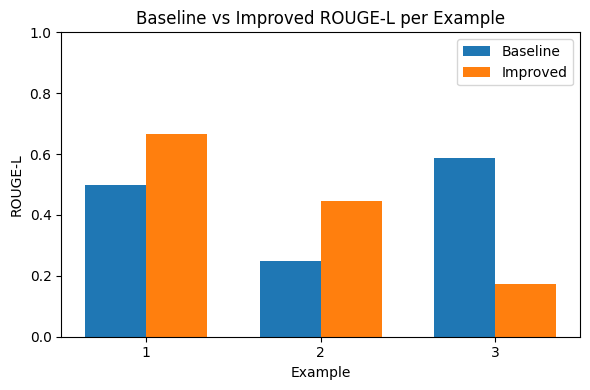

Saved plot: C:\Users\nlope\Desktop\week3\generative_transformer_project\results\rouge_bar.png


In [22]:
df = pd.DataFrame({
    "dialogue": dialogs,
    "reference": refs,
    "baseline_summary": baseline_preds,
    "improved_summary": improved_preds,
    "baseline_rougeL": baseline_scores,
    "improved_rougeL": improved_scores,
})

# 2. Save CSV
results_dir = r"C:\Users\nlope\Desktop\week3\generative_transformer_project\results"
csv_path = results_dir + r"\summarization_results.csv"
df.to_csv(csv_path, index=False)
print(f"Saved CSV: {csv_path}")

# 3. Create bar chart of ROUGE-L scores
examples = np.arange(len(df)) + 1
plt.figure(figsize=(6, 4))
width = 0.35

plt.bar(examples - width/2, df["baseline_rougeL"], width, label="Baseline")
plt.bar(examples + width/2, df["improved_rougeL"], width, label="Improved")

plt.xlabel("Example")
plt.ylabel("ROUGE-L")
plt.title("Baseline vs Improved ROUGE-L per Example")
plt.xticks(examples)
plt.ylim(0, 1.0)
plt.legend()
plt.tight_layout()

# 4. Save plot PNG in the same folder
plot_path = results_dir + r"\rouge_bar.png"
plt.savefig(plot_path, dpi=300)
plt.show()

print(f"Saved plot: {plot_path}")